In [1]:
import glob
import os
import rasterio
from rasterio.warp import reproject, Resampling
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from multiprocessing import Pool
import cv2
from datetime import datetime
import time
from tqdm import tqdm

from sklearnex import patch_sklearn
patch_sklearn()
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.model_selection import train_test_split

Extension for Scikit-learn* enabled (https://github.com/uxlfoundation/scikit-learn-intelex)


In [2]:
CHIRPS_GEOTIFF_DIR = '../../CHIRPS_daily_Uttarakhand'
ERA5_GEOTIFF_DIR = '../../ERA5_daily_Uttarakhand'
# CHIRPS_BAND=1
# ERA5_BAND = 5
def load_geotiff(file_path):
    try:
        filename = os.path.basename(file_path)
        date_str = filename.split("_")[-1].replace(".tif", "")
        date_key = datetime.strptime(date_str, "%Y-%m-%d").date()

        # Open GeoTIFF and read data
        # with rasterio.open(file_path) as dataset:
            ## data = dataset.read(CHIRPS_BAND)
            # data = dataset
        data = rasterio.open(file_path)
        return date_key, data, file_path
    except Exception as e:
        print(f"Failed to load {file_path}: {e}")
        return None, None, file_path
    
# Get list of GeoTIFF files
chirps_geotiff_files = glob.glob(os.path.join(CHIRPS_GEOTIFF_DIR, "CHIRPS_daily_*.tif"))
era5_geotiff_files = glob.glob(os.path.join(ERA5_GEOTIFF_DIR, "ERA5_daily_*.tif"))

# Use multiprocessing to load files in parallel
# with Pool() as pool:
#     chirps_results = pool.map(load_chirps_geotiff, chirps_geotiff_files)
#     era5_results = pool.map(load_era5_geotiff, era5_geotiff_files)

chirps_results = []
era5_results = []
for file_path in chirps_geotiff_files:
    chirps_results.append(load_geotiff(file_path))
for file_path in era5_geotiff_files:
    era5_results.append(load_geotiff(file_path))

# Create dictionary from results
chirps_data_dict = {}
for date_key, data, file_path in chirps_results:
    if date_key is not None and data is not None:
        chirps_data_dict[date_key] = data
        print(f"Loaded {file_path} for date {date_key}")
    else:
        print(f"Skipped {file_path} due to loading error")

era5_data_dict = {}
for date_key, data, file_path in era5_results:
    if date_key is not None and data is not None:
        era5_data_dict[date_key] = data
        print(f"Loaded {file_path} for date {date_key}")
    else:
        print(f"Skipped {file_path} due to loading error")

Loaded ../../CHIRPS_daily_Uttarakhand/CHIRPS_daily_2025-08-12.tif for date 2025-08-12
Loaded ../../CHIRPS_daily_Uttarakhand/CHIRPS_daily_2025-08-28.tif for date 2025-08-28
Loaded ../../CHIRPS_daily_Uttarakhand/CHIRPS_daily_2025-08-18.tif for date 2025-08-18
Loaded ../../CHIRPS_daily_Uttarakhand/CHIRPS_daily_2025-08-19.tif for date 2025-08-19
Loaded ../../CHIRPS_daily_Uttarakhand/CHIRPS_daily_2025-08-14.tif for date 2025-08-14
Loaded ../../CHIRPS_daily_Uttarakhand/CHIRPS_daily_2025-08-21.tif for date 2025-08-21
Loaded ../../CHIRPS_daily_Uttarakhand/CHIRPS_daily_2025-08-24.tif for date 2025-08-24
Loaded ../../CHIRPS_daily_Uttarakhand/CHIRPS_daily_2025-08-22.tif for date 2025-08-22
Loaded ../../CHIRPS_daily_Uttarakhand/CHIRPS_daily_2025-08-09.tif for date 2025-08-09
Loaded ../../CHIRPS_daily_Uttarakhand/CHIRPS_daily_2025-08-13.tif for date 2025-08-13
Loaded ../../CHIRPS_daily_Uttarakhand/CHIRPS_daily_2025-08-31.tif for date 2025-08-31
Loaded ../../CHIRPS_daily_Uttarakhand/CHIRPS_daily_202

In [3]:
chirps_data_dict = dict(sorted(chirps_data_dict.items()))
era5_data_dict = dict(sorted(era5_data_dict.items()))

In [4]:
chirps_dates = list(chirps_data_dict.keys())
chirps_dataset = list(chirps_data_dict.values())

era5_dates = list(era5_data_dict.keys())
era5_dataset = list(era5_data_dict.values())

In [5]:
len(chirps_dates), len(era5_dates)

(16305, 14435)

In [ ]:
def reproject_data(src_dataset, ref_shape, ref_dtype, ref_transform, ref_crs, ref_nodata):
    reprojected = []
    n = 0
    for src in tqdm(src_dataset, desc = "Reprojecting images", colour="GREEN"):
        # 2. Create a destination array with the dimensions and data type of the reference
        # This is where the reprojected data will be stored
        destination_array = np.empty(ref_shape, dtype=ref_dtype)

        # 3. Perform the reprojection
        # This function does all the hard work of warping the source data to the
        # destination grid.
        reproject(
            source=rasterio.band(src, 5),
            destination=destination_array,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=ref_transform, # Apply transform of the reference!
            dst_crs=ref_crs,             # Apply CRS of the reference!
            dst_nodata=ref_nodata,
            resampling=Resampling.bilinear # Choose your resampling method
        )

        # 4. Get the metadata from the reference file to use for the output
        # Update the profile with the correct data type from the reprojected array
        # out_meta = ref.profile.copy()
        # out_meta.update({
        #     "dtype": destination_array.dtype,
        #     "nodata": ref.nodata # Or specify a new nodata value
        # })
        reprojected.append(destination_array)
        src.close()
        # n += 1
        # print(f"Done {n}")
    return reprojected

In [7]:
def fill_nan(image):
    image[np.isnan(image)] = 0.0
    return image

In [8]:
chirps_images = []
for data in tqdm(chirps_dataset, desc = "Storing CHIRPS images", colour="GREEN"):
    image = data.read(1) # Store precipitation band
    image = fill_nan(image)
    chirps_images.append(image)
chirps_images = np.array(chirps_images)

raw_era5_images = []
for data in tqdm(era5_dataset, desc = "Storing raw ERA5 images", colour="GREEN"):
    raw_era5_images.append(data.read(5)) # Store precipitation band
raw_era5_images = np.array(raw_era5_images)

Storing raw ERA5 images: 100%|██████████| 14435/14435 [00:57<00:00, 251.69it/s]


In [14]:
np.sum(np.isnan(chirps_images)), np.sum(np.isinf(chirps_images))

(np.int64(0), np.int64(0))

In [9]:
ref = chirps_dataset[0]
reprojected_era5 = reproject_data(era5_dataset, ref.shape, ref.dtypes[0], ref.transform, ref.crs, ref.nodata)

Reprojecting images: 100%|██████████| 14435/14435 [00:41<00:00, 345.80it/s]


In [10]:
# low_res_images = []
# for image in high_res_images:
#     h, w = image.shape
#     SCALE_FACTOR = 5
#     new_h, new_w = h // SCALE_FACTOR, w // SCALE_FACTOR
#     low_res = cv2.resize(image, (new_w, new_h), interpolation=cv2.INTER_AREA)
#     low_res = cv2.resize(image, (512, 512), interpolation=cv2.INTER_CUBIC)
#     low_res += np.random.normal(0.5, 0.5, size=(512, 512))
#     low_res_images.append(low_res)
# low_res_images = np.array(low_res_images)

In [10]:
reprojected_era5[0].shape, chirps_images[0].shape

((64, 64), (64, 64))

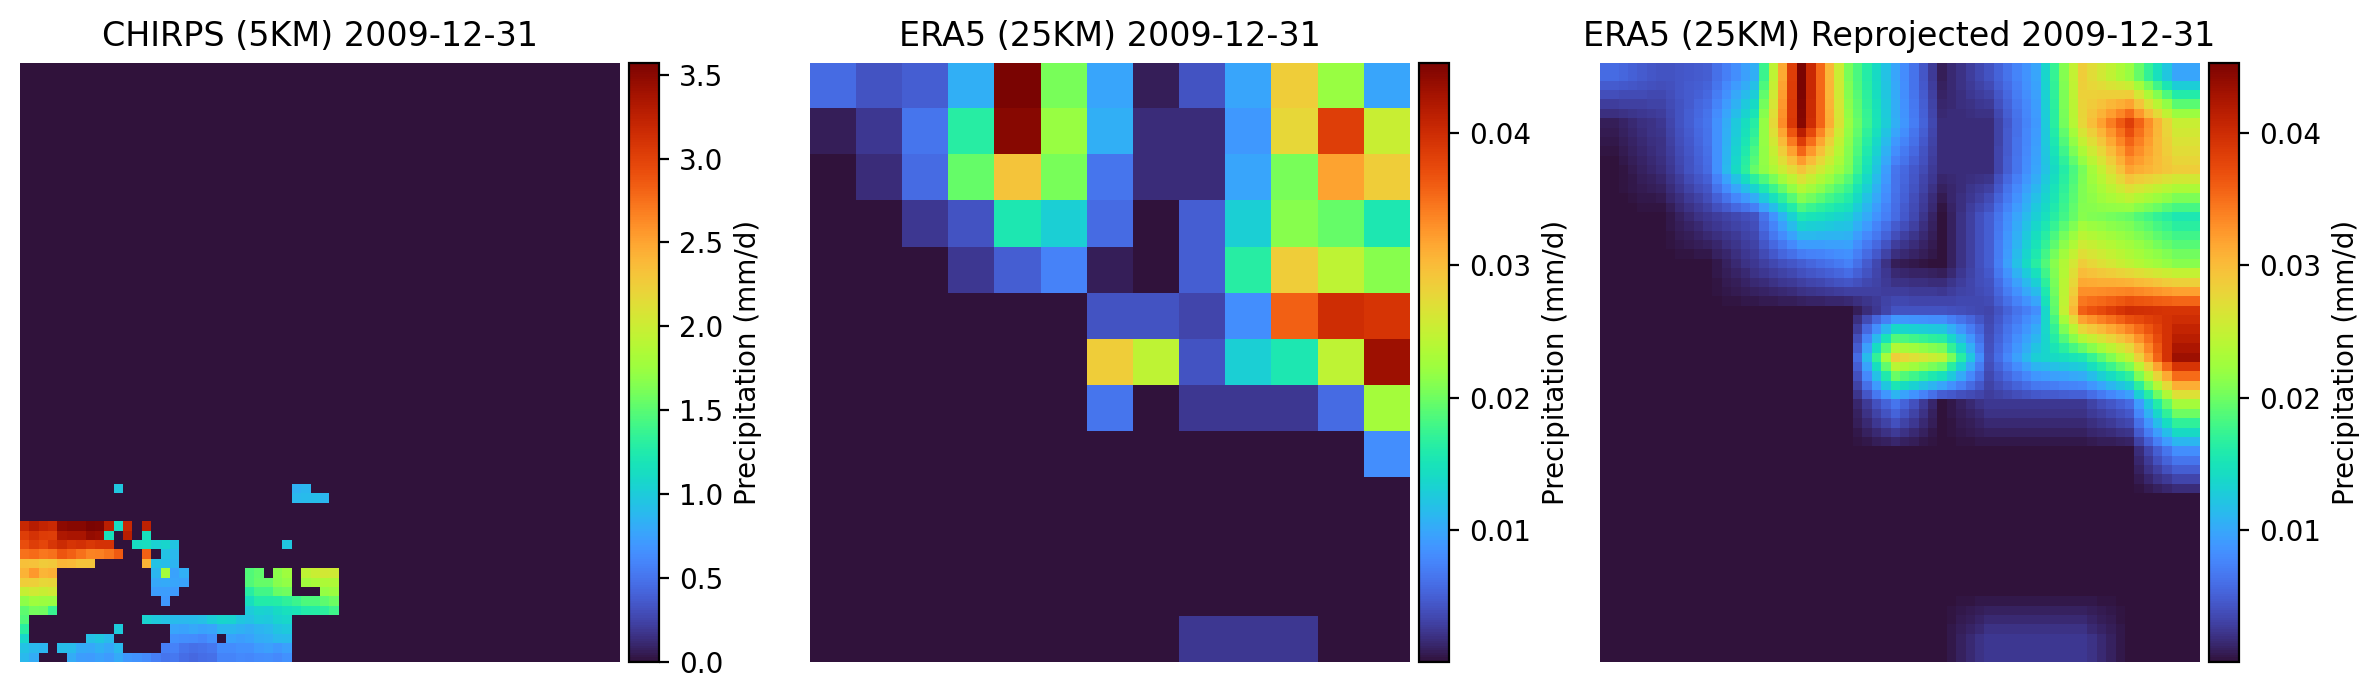

In [11]:
i = 10_591
chirps_image = np.copy(chirps_images[i]) # Get precipitation band
era5_image = np.copy(raw_era5_images[i]*1000) # ERA5 data has precipitation unit in m/d, CHIRPS has in mm/d\
reprojected_era5_image = np.copy(reprojected_era5[i]*1000)

fig, ax = plt.subplots(1, 3, figsize=(12,7), dpi=200)

image_0 = ax[0].imshow(chirps_image, cmap="turbo")
ax[0].set_title(f"CHIRPS (5KM) {chirps_dates[i]}")
ax[0].set_axis_off()
divider = make_axes_locatable(ax[0])
cax = divider.append_axes("right", size="5%", pad=0.05)
plt.colorbar(image_0, cax=cax, orientation="vertical", label="Precipitation (mm/d)")

image_1 = ax[1].imshow(era5_image, cmap="turbo")
ax[1].set_title(f"ERA5 (25KM) {era5_dates[i]}")
ax[1].set_axis_off()
divider = make_axes_locatable(ax[1])
cax = divider.append_axes("right", size="5%", pad=0.05)
plt.colorbar(image_1, cax=cax, orientation="vertical", label="Precipitation (mm/d)")

image_2 = ax[2].imshow(reprojected_era5_image, cmap="turbo")
ax[2].set_title(f"ERA5 (25KM) Reprojected {era5_dates[i]}")
ax[2].set_axis_off()
divider = make_axes_locatable(ax[2])
cax = divider.append_axes("right", size="5%", pad=0.05)
plt.colorbar(image_2, cax=cax, orientation="vertical", label="Precipitation (mm/d)");

# plt.suptitle(f"{chirps_dates[i]}")
plt.tight_layout()
# chirps_image.shape, era5_image.shape

In [12]:
chirps_image.min()

np.float32(0.0)

In [13]:
np.min(chirps_images), np.max(chirps_images)

(np.float32(0.0), np.float32(710.4231))

In [15]:
n = 10_591
X = np.array(reprojected_era5[:n+1])
Y = chirps_images[:n+1]
# y = chirps_images

In [16]:
len(X), len(Y)

(10592, 10592)

In [17]:
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, shuffle=False, random_state=69)

In [40]:
def create_small_images(small_image_size, big_images):
    small_images = {}
    for x in big_images:
        x = x.reshape(-1, small_image_size, small_image_size) # (1024, 16, 16)
        for i, img in enumerate(x):
            if i in small_images:
                small_images[i].append(img.flatten())
            else:
                small_images[i] = [img.flatten()]
    return small_images

In [41]:
def reconstruct_images(small_image_size, predicted_small_images):
    pred_images = []
    for i in range(predicted_small_images.shape[1]):
        pred_images.append(predicted_small_images[:,i,:].reshape(-1, small_image_size, small_image_size).reshape(64, 64))
    return np.array(pred_images)

In [42]:
def postprocess_image(image):
    # Model bias correction 1
    # Replace negative values with zero (-ve precipitation has no meaning)
    image[image < 0] = 0
    return image

In [ ]:
SMALL_IMAGE_SIZE = 8
x_train_small = create_small_images(SMALL_IMAGE_SIZE, x_train)
x_test_small = create_small_images(SMALL_IMAGE_SIZE, x_test)
y_train_small = create_small_images(SMALL_IMAGE_SIZE, y_train)
y_test_small = create_small_images(SMALL_IMAGE_SIZE, y_test)

: 

In [68]:
# np.sum(np.isnan(list(y_train_small.values())))

In [69]:
len(x_test_small)

256

In [70]:
models = []
D = len(x_train)
train_dataset = list(zip(x_train_small.values(), y_train_small.values()))
# train_dataset = list(zip(x_train, y_train))
for x, y in tqdm(train_dataset, desc="Training Models", colour="BLUE"):
    model = LinearRegression(n_jobs=-1)
    # model = RandomForestRegressor(n_estimators=100, n_jobs=-1)
    # model = DecisionTreeRegressor()
    model.fit(x, y)
    models.append(model)

Training Models: 100%|██████████| 256/256 [00:01<00:00, 225.69it/s]


In [71]:
predictions = []
model_and_test_data = list(zip(models, x_test_small.values()))
# model_and_test_data = list(zip(models, x_test))
for model, x in tqdm(model_and_test_data, desc = "Getting Predictions", colour="GREEN"):
    prediction = model.predict(x)
    predictions.append(prediction)
predictions = np.array(predictions)
predictions.shape

Getting Predictions: 100%|██████████| 256/256 [00:00<00:00, 1728.20it/s]


(256, 2119, 16)

In [72]:
pred_images = reconstruct_images(SMALL_IMAGE_SIZE, predictions)
# pred_images = predictions

In [74]:
flattened_test = np.array(y_test).reshape(-1, 64*64)
flattened_pred = pred_images.reshape(-1, 64*64)
mse = mean_squared_error(flattened_test, flattened_pred)
r2 = r2_score(flattened_test, flattened_pred)
print(f"Mean Squred Error = {mse:0.3f}\nR^2 Score = {r2:0.3f}")

Mean Squred Error = 55.066
R^2 Score = 0.104


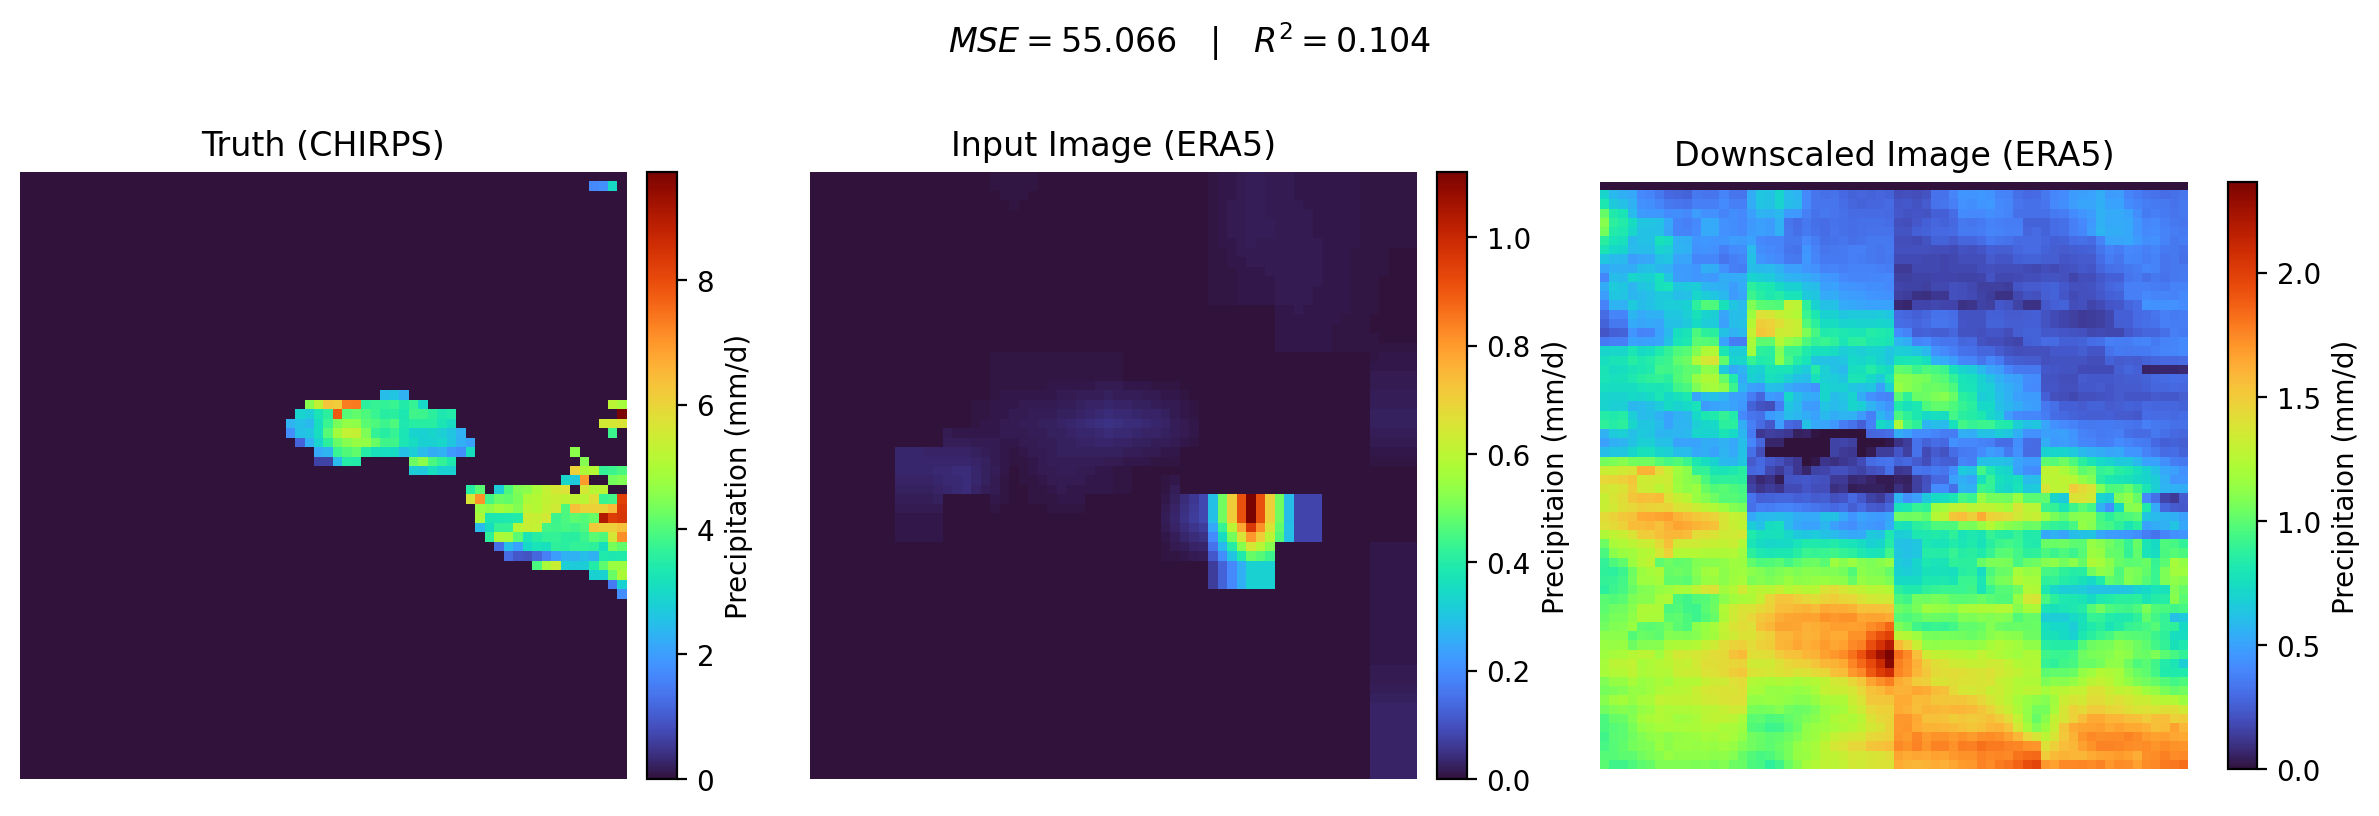

In [75]:
i = 0
fig,axs = plt.subplots(1, 3, figsize=(12,7), dpi=200)

image_0 = axs[0].imshow(y_test[i], cmap="turbo")
axs[0].set_title("Truth (CHIRPS)")
axs[0].set_axis_off()
divider = make_axes_locatable(axs[0])
cax = divider.append_axes("right",size="5%", pad=0.1)
plt.colorbar(image_0, cax=cax, label="Precipitation (mm/d)")

image_1 = axs[1].imshow(x_test[i]*1000, cmap="turbo")
axs[1].set_title("Input Image (ERA5)")
axs[1].set_axis_off()
divider = make_axes_locatable(axs[1])
cax = divider.append_axes("right", size="5%", pad=.1)
plt.colorbar(image_1, cax=cax, label="Precipitaion (mm/d)")

image_2 = axs[2].imshow(postprocess_image(pred_images[i]), cmap="turbo")
axs[2].set_title("Downscaled Image (ERA5)")
axs[2].set_axis_off()
divider = make_axes_locatable(axs[2])
cax = divider.append_axes("right", size="5%", pad=.2)
plt.colorbar(image_2, cax=cax, label="Precipitaion (mm/d)")

plt.suptitle("$MSE = %0.3f \\quad|\\quad R^2 = %0.3f$" %(mse, r2), x=0.5, y=0.8)
plt.tight_layout()

In [93]:
PLOT_SMALL_IMAGES=False

In [94]:
if PLOT_SMALL_IMAGES:
    small_images = predictions[:,0,:].swapaxes(0,1).reshape(-1, SMALL_IMAGE_SIZE, SMALL_IMAGE_SIZE)
    rows = small_images.shape[0]//2
    cols = rows
    fig, axs = plt.subplots(rows, cols, figsize=(12, 12), dpi=500)
    for r in range(rows):
        for c in range(cols):
            idx = r+c
            axs[r, c].imshow(postprocess_image(small_images[idx]), cmap="turbo")
            axs[r, c].set_axis_off()
    plt.subplots_adjust(
        wspace=0.1, # width space between subplots
        hspace=0.1  # height space between subplots
    )
    plt.suptitle("All small images which make up prediction")